In [ ]:
pip install torch torchvision torchaudio


In [1]:
import torch

## 2.1 Создание нейронов и полносвязных слоев

2.1.1. Используя операции над матрицами и векторами из библиотеки `torch`, реализовать нейрон с заданными весами `weights` и `bias`. Прогнать вектор `inputs` через нейрон и вывести результат.

In [ ]:
class Neuron:
  def __init__(self, weights, bias):
    # <создать атрибуты объекта weights и bias>
    self.w = weights
    self.b = bias

  def forward(self, inputs):
    return torch.dot(inputs, self.w) + self.b # <реализовать логику нейрона>


In [ ]:
inputs = torch.tensor([1.0, 2.0, 3.0, 4.0])
weights = torch.tensor([-0.2, 0.3, -0.5, 0.7])
bias = 3.14

In [ ]:
n = Neuron(weights, bias)
n.forward(inputs)

tensor(4.8400)

2.1.2 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать полносвязный слой с заданными весами `weights` и `biases`. Прогнать вектор `inputs` через слой и вывести результат.

In [ ]:
class Linear:
  def __init__(self, weights, biases):
    # <создать атрибуты объекта weights и biases>
    self.w = weights
    self.b = biases

  def forward(self, inputs):
    return torch.mv(self.w, inputs) + self.b

In [ ]:
inputs = torch.tensor([1.0, 2.0, 3.0, 4.0])
weights = torch.tensor([[-0.2, 0.3, -0.5, 0.7],
                        [0.5, -0.91, 0.26, -0.5],
                        [-0.26, -0.27, 0.17, 0.87]])

biases = torch.tensor([3.14, 2.71, 7.2])

In [ ]:
l = Linear(weights, biases)
l.forward(inputs)

tensor([ 4.8400,  0.1700, 10.3900])

torch.dot: перемножает векторы и даёт число.

torch.mv: перемножает матрицу и вектор и даёт вектор.

2.1.3 Рялизовать полносвязный слой из 2.1.2 таким образом, что он мог принимать на вход матрицу(батч)...

In [ ]:
class LinearB:
  def __init__(self, weights, biases):
    # <создать атрибуты объекта weights и biases>
    self.w = weights
    self.b = biases

  def forward(self, inputs):
    return torch.mm(inputs, self.w.T) + self.b

In [ ]:
inputs = torch.tensor([[1, 2, 3, 4],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]])

lb = LinearB(weights, biases)
lb.forward(inputs)

tensor([[ 4.8400,  0.1700, 10.3900],
        [ 6.1400, -2.1000,  6.9000],
        [ 2.0400,  0.7610,  6.7260]])

2.1.4 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать полносвязный слой из `n_neurons` нейронов с `n_features` весами у каждого нейрона (инициализируются из стандартного нормального распределения). Прогнать вектор `inputs` через слой и вывести результат. Результатом прогона сквозь слой должна быть матрица размера `batch_size` x `n_neurons`.

In [ ]:
class Linears:
  def __init__(self, n_features, n_neurons):
    # <создать атрибуты объекта weights и biases>
    self.w = torch.randn(n_features, n_neurons)
    self.b = torch.randn(1, n_neurons)

  def forward(self, inputs):
    return torch.mm(inputs, self.w) + self.b

In [ ]:
inputs = torch.tensor([[1, 2, 3, 4],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]])

ls = Linears(inputs.size()[1], 3)
ls.forward(inputs)

tensor([[ 3.4354,  3.2631,  1.2909],
        [ 3.6267, -1.3861, -1.0820],
        [-0.3439, 10.5964,  5.1775]])

2.1.5 Используя решение из __2.1.4__, создать 2 полносвязных слоя и пропустить матрицу `inputs` последовательно через эти два слоя. Количество нейронов в первом слое выбрать произвольно, количество нейронов во втором слое выбрать так, чтобы результатом прогона являлась матрица (3x7).

In [ ]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]])
n = 100


ls1 = Linears(inputs.size()[1], n)

ls2 = Linears(n, 7)


res1 = ls1.forward(inputs)
res2 = ls2.forward(res1)
res2.size()


torch.Size([3, 7])

In [ ]:
res2


tensor([[-22.8703,  43.5216,  54.1893, -27.8941, -22.9839,  11.4833,  33.1429],
        [-35.0100,  46.5504,  31.4077, -35.0912,  -1.9598, -13.1273, -58.7191],
        [-21.8715,   2.2538,  50.6802, -29.2283,  23.4643, -11.1158,  32.2055]])

ДЗ: решить 2.2

## 2.2 Создание функций активации

2.2.1 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию активации ReLU:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/f4353f4e3e484130504049599d2e7b040793e1eb)

Создать матрицу размера (4,3), заполненную числами из стандартного нормального распределения, и проверить работоспособность функции активации.

In [ ]:
class ReLU:
  def forward(self, inputs):
    # <реализовать логику ReLU>
        return torch.where(inputs < 0, 0, inputs)

In [ ]:
mat = torch.randn((4,3))
mat

tensor([[ 0.3317, -1.3142, -0.2930],
        [-0.5080,  0.2187,  2.0323],
        [ 0.0559,  1.0957,  0.4263],
        [-1.5592, -0.8997, -1.0393]])

In [ ]:
r = ReLU()
r.forward(mat)

tensor([[0.3317, 0.0000, 0.0000],
        [0.0000, 0.2187, 2.0323],
        [0.0559, 1.0957, 0.4263],
        [0.0000, 0.0000, 0.0000]])

2.2.2 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию активации softmax:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/6d7500d980c313da83e4117da701bf7c8f1982f5)

Создать матрицу размера (4,3), заполненную числами из стандартного нормального распределения, и проверить работоспособность функции активации. Строки матрицы трактовать как выходы линейного слоя некоторого классификатора для 4 различных примеров.

In [ ]:
class Softmax:
  def forward(self, inputs):
        # <реализовать логику Softmax>
        # Вычисляем экспоненту от входных значений
        exp_inputs = torch.exp(inputs)
        sum_exp_inputs = torch.sum(exp_inputs, dim=1, keepdim=True)
        # Делим экспоненту от каждого элемента на сумму экспонент по столбцу
        return exp_inputs / sum_exp_inputs

In [ ]:
Softmax().forward(mat)

tensor([[0.1799, 0.1626, 0.6575],
        [0.0207, 0.4420, 0.5373],
        [0.6220, 0.1902, 0.1878],
        [0.4969, 0.3081, 0.1950]])

2.2.3 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию активации ELU:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/eb23becd37c3602c4838e53f532163279192e4fd)

Создать матрицу размера (4,3), заполненную числами из стандартного нормального распределения, и проверить работоспособность функции активации.

In [ ]:
class ELU:
  def __init__(self, alpha):
    # <создать атрибут объекта alpha>
    self.alpha = alpha
    pass

  def forward(self, inputs):
    # <реализовать логику ReLU>
    return torch.where(inputs<0, alpha*(torch.exp(inputs)-1), inputs)

In [ ]:
alpha = 4
elu = ELU(alpha)
elu.forward(mat)

tensor([[ 0.3317, -2.9253, -1.0159],
        [-1.5932,  0.2187,  2.0323],
        [ 0.0559,  1.0957,  0.4263],
        [-3.1588, -2.3732, -2.5853]])

## 2.3 Создание функции потерь

2.3.1 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию потерь MSE:

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/e258221518869aa1c6561bb75b99476c4734108e)

Создать полносвязный слой с 1 нейроном, прогнать через него батч `inputs` и посчитать значение MSE, трактуя вектор `y` как вектор правильных ответов.

In [ ]:
class MSELoss:
  def forward(self, y_pred, y_true):
    return torch.sum((y_true - y_pred)**2)/y_true.size()[0]# <реализовать логику MSE>

In [ ]:
class LinearS:
  def __init__(self):
    # <создать атрибуты объекта weights и biases>
    self.w = torch.randn((4,1))
    self.b = torch.randn((1,1))
    pass

  def forward(self, inputs):
    return torch.mm(inputs, self.w) + self.b  # <реализовать логику слоя>

In [ ]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]])

ls = LinearS()

In [ ]:
y1 = ls.forward(inputs).reshape(3,)
y = torch.tensor([2, 3, 4])
y1

tensor([ 0.4228, -3.6263, -7.3561])

In [ ]:
mse = MSELoss()
mse.forward(y1,y)

tensor(58.4526)

2.3.2 Используя операции над матрицами и векторами из библиотеки `torch`, реализовать функцию потерь Categorical Cross-Entropy:

<img src="https://i.ibb.co/93gy1dN/Screenshot-9.png" width="200">

Создать полносвязный слой с 3 нейронами и прогнать через него батч `inputs`. Полученный результат пропустить через функцию активации softmax. Посчитать значение CCE, трактуя вектор `y` как вектор правильных ответов.

In [ ]:
class CategoricalCrossentropyLoss:
  def forward(self, y_pred, y_true):
    # <реализовать логику CCE>
    return -torch.sum(y_true * torch.log(y_pred))

In [ ]:
class LinearS:
  def __init__(self):
    # <создать атрибуты объекта weights и biases>
    self.w = torch.randn((4,3))
    self.b = torch.randn((3,1))
    pass

  def forward(self, inputs):
    return torch.mm(inputs, self.w) + self.b  # <реализовать логику слоя>

In [ ]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                        [2, 5, -1, 2],
                        [-1.5, 2.7, 3.3, -0.8]])

y = torch.tensor([[1, 0, 0]])
ls = LinearS()
out = ls.forward(inputs)
out = torch.softmax(out, dim=1)
cce = CategoricalCrossentropyLoss()
loss = cce.forward(out, y)
print(loss)

tensor(18.0364)


2.3.3 Модифицировать 2.3.1, добавив L2-регуляризацию.

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/d92ca2429275bfdc0474523babbafe014ca8b580)


In [ ]:
class MSELossL2:
  def __init__(self, lambda_):
    # <создать атрибут объекта alpha>
    self.lambda_ = lambda_

  def data_loss(self, y_pred, y_true):
    # <подсчет первого слагаемого из формулы>
    mse = MSELoss()
    return mse.forward(y_true, y_pred)

  def reg_loss(self, layer):
    weights = layer.w
    return self.lambda_ * torch.sum(weights**2)

  def forward(self, y_pred, y_true, layer):
    return self.data_loss(y_pred, y_true) + self.reg_loss(layer)

In [ ]:
class LinearS:
  def __init__(self, n_features, n_neurons):
    # <создать атрибуты объекта weights и biases>
    self.w = torch.randn(n_features, n_neurons)
    self.b = torch.randn(1,n_neurons)
    pass

  def forward(self, inputs):
    return torch.mm(inputs, self.w) + self.b  # <реализовать логику слоя>

In [ ]:
layer = LinearS(4,1)

In [ ]:
inputs = torch.tensor([[1, 2, 3, 2.5],
                       [2, 5, -1, 2],
                       [-1.5, 2.7, 3.3, -0.8]])

y = torch.tensor([2, 3, 4])
y1 = layer.forward(inputs).reshape(3)

In [ ]:
msereg = MSELossL2(5)
msereg.forward(y1, y, layer)

tensor(21.2459)

## 2.4 Обратное распространение ошибки

2.4.1 Используя один нейрон и SGD (1 пример за шаг), решите задачу регрессии

In [ ]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5)
X = torch.from_numpy(X).to(dtype = torch.float32) # <преобразуйте массивы numpy в тензоры torch с типом torch.float32
y = torch.from_numpy(y).to(dtype = torch.float32) # <преобразуйте массивы numpy в тензоры torch с типом torch.float32

[Граф вычислений для этой задачи](https://i.ibb.co/2dhDxZx/photo-2021-02-15-17-18-04.jpg)

2.4.1.1 Реализуйте класс `SquaredLoss`


In [ ]:
class SquaredLoss:
  def forward(self, y_pred, y_true):
    return (y_pred-y_true)**2  # <реализовать логику MSE>

  def backward(self, y_pred, y_true):
    self.dinput = 2*(y_pred-y_true)# df/dc


2.4.1.2. Модифицируйте класс `Neuron` из __2.1.1__:

  1) Сделайте так, чтобы веса нейрона инициализировались из стандартного нормального распределения

  2) Реализуйте расчет градиента относительно весов `weights` и `bias`

In [ ]:
class Neuron:
  def __init__(self, n_inputs):
    # <создать атрибуты объекта weights и bias>
    self.w = torch.randn(n_inputs)
    self.b = torch.randn(1) #1 потому что 1 нейрон на выходе

  def forward(self, inputs):
    self.inputs = inputs
    return inputs.dot(self.w) + self.b# <реализовать логику нейрона>

  def backward(self, dvalue):
    # dvalue = 2(y_pred=y_true) - значение производной, которое приходит нейрону от следующего слоя сети
    # в данном случае это будет значение df/dc (созданное методом backwards у объекта MSELoss)
    self.dweights = dvalue*self.inputs # df/dW
    self.dinput =  dvalue * self.w # df/wX исп когда несколько слоев
    self.dbias = dvalue*1# df/db


2.4.1.3 Допишите цикл для настройки весов нейрона

[SGD](https://ru.wikipedia.org/wiki/%D0%A1%D1%82%D0%BE%D1%85%D0%B0%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B9_%D0%B3%D1%80%D0%B0%D0%B4%D0%B8%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B9_%D1%81%D0%BF%D1%83%D1%81%D0%BA)

![](https://wikimedia.org/api/rest_v1/media/math/render/svg/dda3670f8a8996a0d3bf80856bb4a166cc8db6d4)

In [ ]:
n_inputs = X.size()[1] # <размерность элемента выборки >
lr = 0.1 #  скорость обучения
n_epoch = 100 #  количество эпох

neuron = Neuron(n_inputs)
loss = SquaredLoss()

losses = []
neuron.w

tensor([ 0.1584, -0.0907, -0.4664,  0.4510])

In [ ]:
for epoch in range(100):
  for x_example, y_example in zip(X, y):
    # forward pass
    y_pred = neuron.forward(x_example) # <прогон через нейрон>
    curr_loss = loss.forward(y_pred, y_example)# <прогон через функцию потерь>
    losses.append(curr_loss)

    # backprop
    # <вызов методов backward>
    loss.backward(y_pred, y_example)
    # обратите внимание на последовательность вызовов: от конца к началу
    neuron.backward(loss.dinput)
    # <шаг оптимизации для весов (weights и bias) нейрона>
    neuron.w -= lr*neuron.dweights
    neuron.b -= lr*neuron.dbias

In [ ]:
neuron.w

tensor([71.8911, 40.5531, 26.0566, 93.9520])

In [ ]:
coef

array([71.89111215, 40.55308012, 26.05654506, 93.9519826 ])

In [ ]:
from matplotlib import pyplot as plt

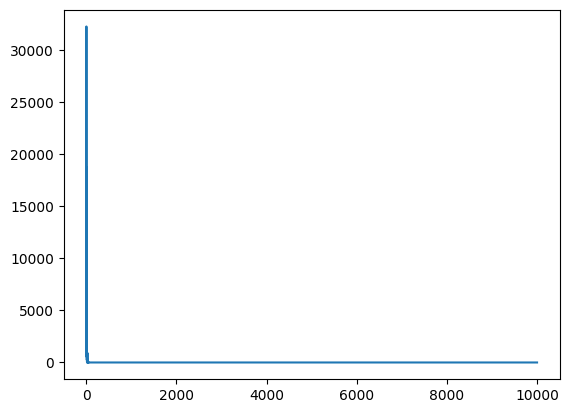

In [ ]:
plt.plot(losses)

2.4.2 Решите задачу 2.4.1, используя пакетный градиентный спуск

Вычисления для этой задачи:
[1](https://i.ibb.co/rmtQT6P/photo-2021-02-15-18-00-43.jpg)
[2](https://i.ibb.co/NmCFVnQ/photo-2021-02-15-18-01-17.jpg)

2.4.1.1 Модифицируйте класс `MSELoss` из __2.3.1__, реализовав расчет производной относительно предыдущего слоя с учетом того, что теперь работа ведется с батчами, а не с индивидуальными примерами


In [ ]:
class MSELossNEW:
  def forward(self, y_pred, y_true):
    return ((y_pred-y_true)**2).mean()# <реализовать логику MSE>

  def backward(self, y_pred, y_true):
    self.dinput = 2* (y_pred - y_true)/y_pred.shape[0]# df/dy^

2.4.2.2. Модифицируйте класс `Neuron` из __2.4.1.2__:

  1) Реализуйте метод `forward` таким образом, чтобы он мог принимать на вход матрицу (батч) с данными.

  2) Реализуйте расчет градиента относительно весов `weights` и `bias` с учетом того, что теперь работа ведется с батчами, а не с индивидуальными примерами

In [ ]:
class Neuron:
  def __init__(self, n_inputs):
    # <создать атрибуты объекта weights и bias>
    self.w = torch.randn(n_inputs)
    self.b = torch.randn(1) #1 потому что 1 нейрон на выходе

  def forward(self, inputs):
    self.inputs = inputs
    return torch.matmul(inputs, self.w) + self.b# <реализовать логику нейрона>

  def backward(self, dvalue):
    # dvalue = 2(y_pred=y_true) - значение производной, которое приходит нейрону от следующего слоя сети
    # в данном случае это будет значение df/dc (созданное методом backwards у объекта MSELoss)
    self.dweights = torch.matmul(self.inputs.T, dvalue) # df/dW
    self.dinput =  dvalue.reshape(-1,1) * self.w # df/wX исп когда несколько слоев
    self.dbias = dvalue.mean()# df/db


2.4.2.3 Допишите цикл для настройки весов нейрона

In [ ]:
n_inputs = X.size()[1]
lr = 0.1 #  скорость обучения
n_epoch = 50 #  количество эпох

neuron = Neuron(n_inputs)
loss = MSELossNEW()
losses = []

for epoch in range(100):
    # forward pass
    y_pred = neuron.forward(X)# <прогон через нейрон>
    curr_loss = loss.forward(y_pred,y)# <прогон через функцию потерь>
    losses.append(curr_loss)

    # backprop
    # <вызов методов backward>
    # обратите внимание на последовательность вызовов: от конца к началу
    loss.backward(y_pred, y)
    neuron.backward(loss.dinput)

    neuron.w -= lr * neuron.dweights
    neuron.b -= lr * neuron.dbias

    # <шаг оптимизации для весов (weights и bias) нейрона>

In [ ]:
neuron.w

tensor([71.8814, 40.5566, 26.0427, 93.9742])

In [ ]:
coef

array([71.89111215, 40.55308012, 26.05654506, 93.9519826 ])

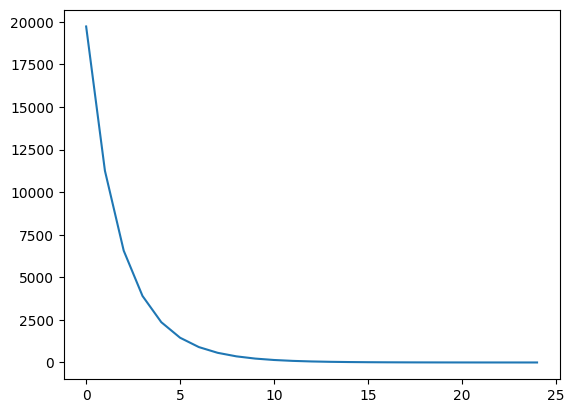

In [ ]:
plt.plot(losses[:25])

2.4.3  Используя один полносвязный слой и  пакетный градиетный спуск, решите задачу регрессии из __2.4.1__

2.4.3.1 Модифицируйте класс `Linear` из __2.1.4__. ([вычисление градиентов](https://i.ibb.co/kgVR6m6/photo-2021-02-15-21-30-28.jpg))

In [ ]:
class LinearSPack:
  def __init__(self, n_features, n_neurons):
    self.w = torch.randn(n_features, n_neurons)
    self.b = torch.randn(1, n_neurons)

  def forward(self, inputs):
    self.inputs = inputs
    return torch.matmul(inputs, self.w) + self.b# <реализовать логику слоя>

  def backward(self, dvalue):
    self.dweights = torch.matmul(self.inputs.T, dvalue) # df/dW
    self.dbiases = dvalue.mean() # df/db
    self.dinputs = dvalue.reshape(-1,1) # df/dX

2.4.3.2 Создайте слой с одним нейроном. Используя класс MSELoss из 2.4.2, убедитесь, что модель обучается

In [ ]:
class MSELossNEW:
  def forward(self, y_pred, y_true):
    return ((y_pred-y_true)**2).mean()# <реализовать логику MSE>

  def backward(self, y_pred, y_true):
    self.dinput = 2* (y_pred - y_true)/y_pred.shape[0]# df/dy^|


In [ ]:
n_features = X.size()[1]
lr = 0.1 #  скорость обучения
n_epoch = 50 #  количество эпох

neuron = LinearSPack(n_features, 4)
loss = MSELossNEW()
losses = []

for epoch in range(100):
    # forward pass
    y_pred = neuron.forward(X) # <прогон через нейрон>
    curr_loss = loss.forward(y_pred, y.reshape(-1,1)) # <прогон через функцию потерь>
    losses.append(curr_loss)

    # backprop
    # <вызов методов backward>
    # обратите внимание на последовательность вызовов: от конца к началу
    loss.backward(y_pred, y.reshape(-1,1))
    neuron.backward(loss.dinput)

    neuron.w -= lr * neuron.dweights
    neuron.b -= lr * neuron.dbiases

    # <шаг оптимизации для весов (weights и bias) нейрона>

In [ ]:
neuron.w

tensor([[71.9371, 71.9260, 71.9143, 71.9963],
        [40.5361, 40.5402, 40.5444, 40.5144],
        [26.1223, 26.1064, 26.0898, 26.2065],
        [93.8462, 93.8717, 93.8984, 93.7110]])

In [ ]:
coef

array([71.89111215, 40.55308012, 26.05654506, 93.9519826 ])

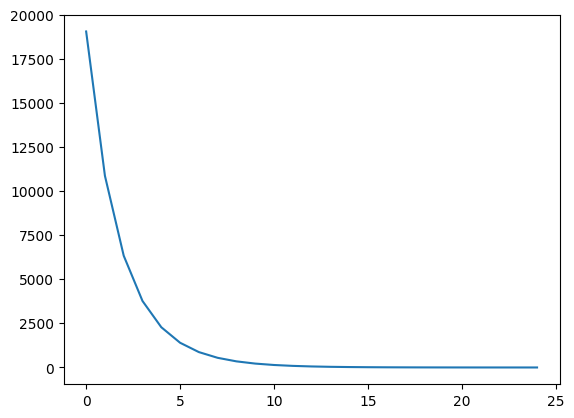

In [ ]:
plt.plot(losses[:25])

2.4.4 Используя наработки из 2.4, создайте нейросеть и решите задачу регрессии.

Предлагаемая архитектура:
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

In [ ]:
X = torch.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * torch.rand(X.size())

In [ ]:
class Activation_ReLU:
  def forward(self, inputs):
    self.inputs = inputs
    self.output = inputs.clip(min=0)
    return self.output

  def backward(self, dvalues):
    self.dinputs = dvalues.clone()
    self.dinputs[self.inputs <= 0] = 0

In [ ]:
# создание компонентов сети
# fc1 =
# relu1 =
# fc2 =

loss = MSELoss()
lr = 0.02

ys = []
for epoch in range(2001):
  # <forward pass>
  # fc1 > relu1 > fc2 > loss

  data_loss = # <прогон через функцию потерь>

  if epoch % 200 == 0:
    print(f'epoch {epoch} mean loss {data_loss}')
    ys.append(out)

  # <backprop>
  # loss > fc2 > relu1 > fc1

  # <шаг оптимизации для fc1>

  # <шаг оптимизации для fc2>


In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(ys), 1, figsize=(10, 40))
for ax, y_ in zip(axs, ys):
  ax.scatter(X.numpy(), y.numpy(), color = "orange")
  ax.plot(X.numpy(), y_.numpy(), 'g-', lw=3)
  ax.set_xlim(-1.05, 1.5)
  ax.set_ylim(-0.25, 1.25)